# HW-0914 · Q8 — Exploring the `College` data set

ISLP §2.4, Exercise 8. Parts (a)–(h) as set out in the book.

### (a) Read the data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

CANDIDATES = [
    "data/College.csv",
    "College.csv",
]
path = next((p for p in CANDIDATES if Path(p).exists()), None)
if path is None:
    import urllib.request
    Path("data").mkdir(exist_ok=True)
    urllib.request.urlretrieve("https://www.statlearning.com/s/College.csv", "data/College.csv")
    path = "data/College.csv"

college = pd.read_csv(path)
print(path, college.shape)
college.head()

data/College.csv (777, 19)


,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


### (b) Fix the index

The first column is the college name, not data — `pandas` is calling it `Unnamed: 0`. Set it
as the index instead of treating it as a feature.

In [2]:
college3 = college.rename({"Unnamed: 0": "College"}, axis=1)
college3 = college3.set_index("College")
college = college3
college.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
College,,,,,,,,,,,,,,,,,,
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


### (c) Numerical summary

In [3]:
college.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


### (d) Scatterplot matrix — `Top10perc`, `Apps`, `Enroll`

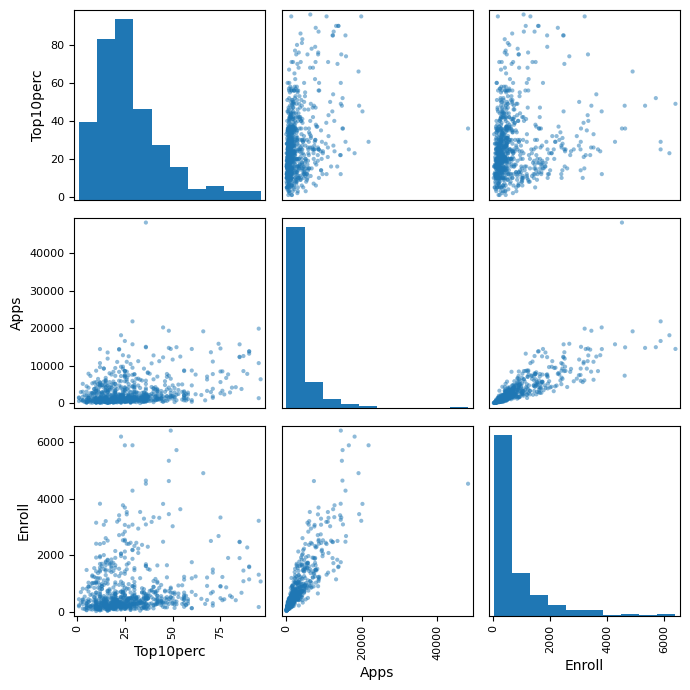

In [4]:
pd.plotting.scatter_matrix(college[["Top10perc", "Apps", "Enroll"]], figsize=(7, 7))
plt.tight_layout()
plt.show()

### (e) `Outstate` vs. `Private`

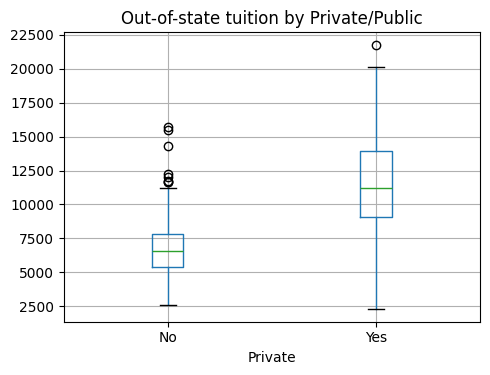

In [5]:
college.boxplot(column="Outstate", by="Private", figsize=(5, 4))
plt.suptitle("")
plt.title("Out-of-state tuition by Private/Public")
plt.tight_layout()
plt.show()

### (f) `Elite` — top-10%-of-class share above 50%

Elite
No     699
Yes     78
Name: count, dtype: int64


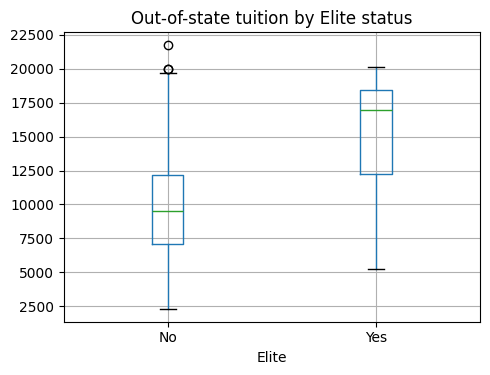

In [6]:
college["Elite"] = pd.cut(college["Top10perc"], [0, 50, 100], labels=["No", "Yes"])
print(college["Elite"].value_counts())

college.boxplot(column="Outstate", by="Elite", figsize=(5, 4))
plt.suptitle("")
plt.title("Out-of-state tuition by Elite status")
plt.tight_layout()
plt.show()

### (g) Histograms

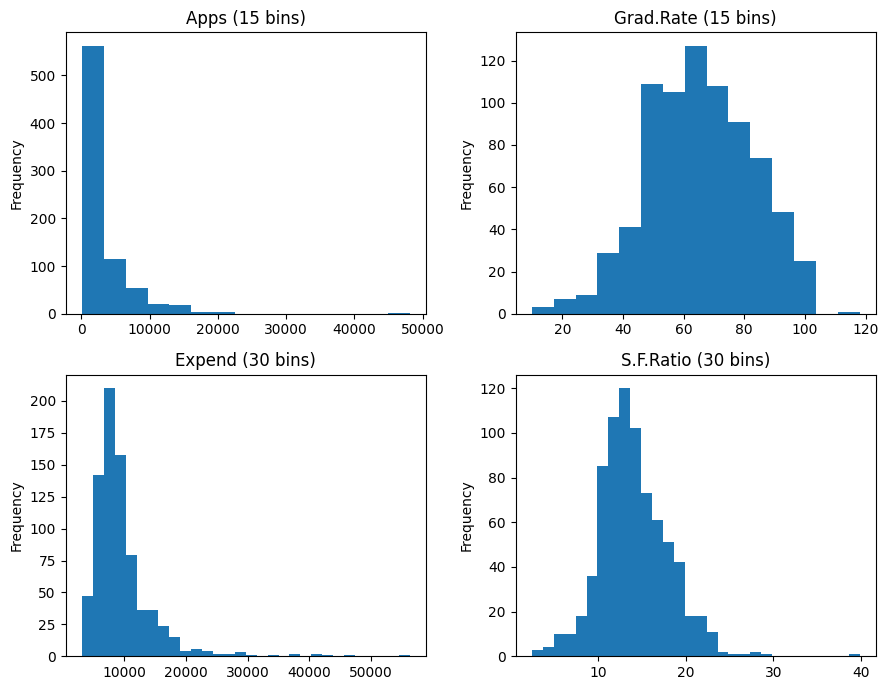

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
college["Apps"].plot.hist(ax=axes[0, 0], bins=15, title="Apps (15 bins)")
college["Grad.Rate"].plot.hist(ax=axes[0, 1], bins=15, title="Grad.Rate (15 bins)")
college["Expend"].plot.hist(ax=axes[1, 0], bins=30, title="Expend (30 bins)")
college["S.F.Ratio"].plot.hist(ax=axes[1, 1], bins=30, title="S.F.Ratio (30 bins)")
plt.tight_layout()
plt.show()

### (h) One claim, one figure

The `Grad.Rate` histogram above has a bar sitting past 100 — a graduation rate can't exceed
100%. Find out which school, and whether it's the only one.

In [8]:
over_100 = college[college["Grad.Rate"] > 100]
print("schools with Grad.Rate > 100:", len(over_100))
over_100[["Grad.Rate", "Private", "Outstate", "Top10perc"]]

schools with Grad.Rate > 100: 1


,Grad.Rate,Private,Outstate,Top10perc
College,,,,
Cazenovia College,118,Yes,9384,9


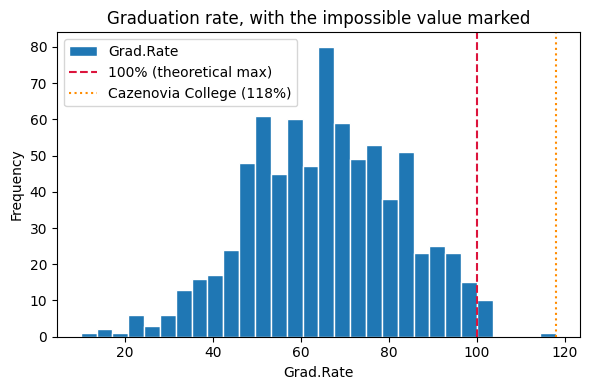

In [9]:
plt.figure(figsize=(6, 4))
college["Grad.Rate"].plot.hist(bins=30, edgecolor="white")
plt.axvline(100, color="crimson", linestyle="--", label="100% (theoretical max)")
plt.axvline(college.loc["Cazenovia College", "Grad.Rate"], color="darkorange",
            linestyle=":", label="Cazenovia College (118%)")
plt.xlabel("Grad.Rate")
plt.legend()
plt.title("Graduation rate, with the impossible value marked")
plt.tight_layout()
plt.show()

**Claim (could be wrong):** Cazenovia College is recorded with a `Grad.Rate` of **118%**, which is
not a possible value for a graduation rate — this is the only row past 100, out of 777. My
claim: this single row reflects **a data-entry or definitional error** (e.g. counting transfer-in
students against the original cohort denominator), not a real institution graduating more
students than it enrolled.

This could be wrong the other way, too: some institutional reporting conventions do allow a
graduation rate above 100% under specific cohort definitions, in which case the value is real but
not comparable to every other row's definition — either way, the practical conclusion is the
same.

**Why it matters for modelling:** at minimum this single value should be capped at 100 or dropped
before `Grad.Rate` is used as a response or feature — left as-is, it silently overstates the
maximum of the variable and would corrupt anything that assumes `Grad.Rate` lies in [0, 100]
(e.g. a probability-style target, or a min–max scaler).